# Разведочный анализ RFSD (Russian Financial Statements Database)

**Данные:** [RFSD](https://github.com/irlcode/RFSD) — открытая база годовой неконсолидированной
бухгалтерской отчётности российских фирм за 2011–2024 гг. (источники — Росстат и ФНС; формат
Apache Parquet с партиционированием по годам; хостинг — [Hugging Face](https://huggingface.co/datasets/irlspbru/RFSD)).

**Ограничение — 20 колонок × 1000 строк.** Полный датасет — 6.6 ГБ и ~210 переменных, поэтому:
берём одну партицию (`year=2023`), запрашиваем только 20 нужных колонок (Parquet колоночный —
остальные физически не читаются) и идём по файлу батчами. Данные внутри года не перемешаны,
поэтому «первые 1000 строк» дали бы смещённую выборку — применяем резервуарную выборку.

**План:** загрузка → описательная статистика → гистограммы и выбросы → матрица корреляций →
диаграммы рассеивания → проверка бухгалтерских тождеств → выводы.

## 1. Загрузка данных

In [1]:
# !pip install pandas numpy pyarrow huggingface_hub matplotlib seaborn

import os
import warnings

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
YEAR = 2023        # анализируемая партиция
N_ROWS = 1000      # ограничение по заданию
BATCH_SIZE = 50_000
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10, "font.size": 10,
})
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)

pandas 2.2.2 | numpy 2.0.2 | seaborn 0.13.2


### 1.1. Выбор 20 колонок

Имена переменных в RFSD — номера строк бухгалтерских форм (`line_1600`); человекочитаемые
имена берутся из
[`aux_data/descriptive_names_dict.csv`](https://raw.githubusercontent.com/irlcode/RFSD/main/aux_data/descriptive_names_dict.csv)
(`B_` — баланс, `PL_` — отчёт о финансовых результатах).

Колонки подобраны так, чтобы получить связный срез фирмы: обе стороны баланса, вся цепочка
формирования прибыли и две небухгалтерские характеристики (возраст, тип отчётности).
Все 20 колонок числовые — значит, корреляционная матрица считается по всем двадцати.

Денежные показатели хранятся **в тысячах рублей**, как в оригинальных формах отчётности.

In [2]:
COLUMNS_20 = [
    "age",         # возраст фирмы, лет
    "simplified",  # 1 = сдана упрощённая форма отчётности
    # баланс, актив
    "line_1100",   # внеоборотные активы
    "line_1150",   # основные средства
    "line_1200",   # оборотные активы
    "line_1210",   # запасы
    "line_1230",   # дебиторская задолженность
    "line_1250",   # денежные средства
    "line_1600",   # БАЛАНС (актив)
    # баланс, пассив
    "line_1300",   # капитал и резервы
    "line_1400",   # долгосрочные обязательства
    "line_1500",   # краткосрочные обязательства
    "line_1700",   # БАЛАНС (пассив)
    # отчёт о финансовых результатах
    "line_2110",   # выручка
    "line_2120",   # себестоимость продаж
    "line_2100",   # валовая прибыль
    "line_2200",   # прибыль от продаж
    "line_2300",   # прибыль до налогообложения
    "line_2400",   # чистая прибыль
    "line_2410",   # налог на прибыль
]
assert len(COLUMNS_20) == 20

RENAME = {
    "line_1100": "B_noncurrent_assets", "line_1150": "B_fixed_assets",
    "line_1200": "B_current_assets",    "line_1210": "B_inventories",
    "line_1230": "B_accounts_receivable", "line_1250": "B_cash_equivalents",
    "line_1600": "B_assets",            "line_1300": "B_total_equity",
    "line_1400": "B_longterm_liab",     "line_1500": "B_shortterm_liab",
    "line_1700": "B_liab",              "line_2110": "PL_revenue",
    "line_2120": "PL_cost_of_sales",    "line_2100": "PL_gross_profit",
    "line_2200": "PL_profit_from_sales", "line_2300": "PL_before_tax",
    "line_2400": "PL_net_profit",       "line_2410": "PL_income_tax",
}

# подписи для графиков
LABELS_RU = {
    "age": "Возраст фирмы, лет",
    "simplified": "Упрощённая отчётность (0/1)",
    "B_noncurrent_assets": "Внеоборотные активы",
    "B_fixed_assets": "Основные средства",
    "B_current_assets": "Оборотные активы",
    "B_inventories": "Запасы",
    "B_accounts_receivable": "Дебиторская задолженность",
    "B_cash_equivalents": "Денежные средства",
    "B_assets": "Баланс (актив)",
    "B_total_equity": "Капитал и резервы",
    "B_longterm_liab": "Долгосрочные обязательства",
    "B_shortterm_liab": "Краткосрочные обязательства",
    "B_liab": "Баланс (пассив)",
    "PL_revenue": "Выручка",
    "PL_cost_of_sales": "Себестоимость продаж",
    "PL_gross_profit": "Валовая прибыль",
    "PL_profit_from_sales": "Прибыль от продаж",
    "PL_before_tax": "Прибыль до налогообложения",
    "PL_net_profit": "Чистая прибыль",
    "PL_income_tax": "Налог на прибыль",
}

### 1.2. Потоковое чтение + резервуарная выборка

**Как читаем.** По умолчанию (`STREAM_OVER_NETWORK = True`) файл партиции не скачивается вовсе:
pyarrow запрашивает по HTTP только те диапазоны байт, где лежат нужные 20 колонок нужных
row-групп, и отдаёт данные батчами. `SCAN_ROWS` ограничивает объём просмотра, отбирая row-группы,
равномерно разбросанные по файлу; читать подряд идущие строки нельзя — данные внутри года
не перемешаны. Если сеть тормозит, `STREAM_OVER_NETWORK = False` один раз положит файл партиции
(~0.5 ГБ из 6.6 ГБ датасета) в кэш Hugging Face и дальше будет читать его с диска.

**Выборка.** Каждой строке приписывается случайный ключ `U(0, 1)`; в резервуаре остаются 1000 строк
с наименьшими ключами. Это равновероятная выборка из просмотренных данных, а память не растёт
с размером файла — в ней одновременно только текущий батч и 1000 строк. При `SCAN_ROWS = None`
просматривается вся партиция и выборка получается равновероятной по всей партиции; при
ограниченном `SCAN_ROWS` — по нескольким row-группам, разбросанным по всему файлу.

In [3]:
STREAM_OVER_NETWORK = True   # True  — читаем по сети батчами, ничего не скачивая
                             # False — кладём файл партиции (~0.5 ГБ) в кэш HF и читаем с диска
SCAN_ROWS = 300_000          # сколько строк партиции просматривать при чтении по сети (None — всю)
MIN_ROW_GROUPS = 3           # минимум row-групп, чтобы выборка не пришла из одного куска файла


def partition_files(year):
    """Файлы партиции: путь, функция открытия и лимит просмотра строк."""
    local_path = os.environ.get("RFSD_LOCAL_PATH")
    if local_path:
        return [local_path], (lambda p: open(p, "rb")), None      # с диска дёшево прочитать всё

    from huggingface_hub import HfFileSystem, hf_hub_download
    fs = HfFileSystem()
    paths = sorted(fs.glob(f"datasets/irlspbru/RFSD/RFSD/year={year}/*.parquet"))
    if not paths:
        raise FileNotFoundError(f"партиция year={year} не найдена на Hugging Face")

    if not STREAM_OVER_NETWORK:
        cached = [hf_hub_download("irlspbru/RFSD", path.split("irlspbru/RFSD/", 1)[1],
                                  repo_type="dataset") for path in paths]
        return cached, (lambda p: open(p, "rb")), None

    return paths, (lambda p: fs.open(p, "rb")), SCAN_ROWS


def pick_row_groups(parquet_file, scan_rows):
    """Row-группы, равномерно разбросанные по файлу и покрывающие ~scan_rows строк."""
    sizes = [parquet_file.metadata.row_group(i).num_rows for i in range(parquet_file.num_row_groups)]
    if not scan_rows or sum(sizes) <= scan_rows:
        return None                                               # None = читать все row-группы
    k = min(len(sizes), max(MIN_ROW_GROUPS, round(scan_rows / (sum(sizes) / len(sizes)))))
    return sorted({int(i) for i in np.linspace(0, len(sizes) - 1, k)})


def iter_batches(year, columns):
    """Батчи партиции: за раз в память попадает только BATCH_SIZE строк по 20 колонкам."""
    paths, opener, scan_rows = partition_files(year)
    for path in paths:
        with opener(path) as fh:
            pf = pq.ParquetFile(fh, pre_buffer=True)               # pre_buffer ускоряет чтение по сети
            groups = pick_row_groups(pf, scan_rows)
            print(f"{path}\n  row-групп: {pf.num_row_groups}, "
                  f"читаем: {'все' if groups is None else len(groups)}")
            yield from pf.iter_batches(batch_size=BATCH_SIZE, columns=columns, row_groups=groups)


def load_rfsd(year=YEAR, columns=COLUMNS_20, n_rows=N_ROWS, seed=RANDOM_STATE):
    """Равновероятная выборка n_rows строк без загрузки партиции в память."""
    rng = np.random.default_rng(seed)
    reservoir, total = None, 0

    for batch in iter_batches(year, columns):
        chunk = batch.to_pandas()
        chunk["_key"] = rng.random(len(chunk))
        total += len(chunk)
        reservoir = chunk if reservoir is None else pd.concat([reservoir, chunk], ignore_index=True)
        reservoir = reservoir.nsmallest(n_rows, "_key")
        print(f"  просмотрено строк: {total:,}", end="\r")

    print(f"\nвсего просмотрено строк: {total:,}")
    return reservoir.drop(columns="_key").reset_index(drop=True)


raw = load_rfsd()
df = raw.rename(columns=RENAME)[[RENAME.get(col, col) for col in COLUMNS_20]].astype("float64")

print(f"выборка: {df.shape[0]} строк × {df.shape[1]} колонок")
df.head()

datasets/irlspbru/RFSD/RFSD/year=2023/part-0.parquet
  row-групп: 1835, читаем: 171
  просмотрено строк: 314,185
всего просмотрено строк: 314,185
выборка: 1000 строк × 20 колонок


,age,simplified,B_noncurrent_assets,B_fixed_assets,B_current_assets,B_inventories,B_accounts_receivable,B_cash_equivalents,B_assets,B_total_equity,B_longterm_liab,B_shortterm_liab,B_liab,PL_revenue,PL_cost_of_sales,PL_gross_profit,PL_profit_from_sales,PL_before_tax,PL_net_profit,PL_income_tax
0,14.00,0.00,785.00,785.00,"1,764.00","1,764.00",NaN,NaN,"2,549.00","1,560.00",NaN,989.00,"2,549.00",787.00,-542.00,245.00,245.00,"-3,615.00","-3,615.00",NaN
1,1.00,0.00,NaN,NaN,144.00,142.00,0.00,2.00,144.00,144.00,NaN,NaN,144.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,15.00,0.00,"52,067.00","46,657.00","174,936.00","119,997.00","53,290.00","1,649.00","227,003.00","93,104.00",NaN,"133,899.00","227,003.00","84,489.00","-78,279.00","6,210.00","6,210.00","7,689.00","7,496.00",-193.00
4,7.00,0.00,0.00,0.00,"19,265.00",10.00,"19,006.00",228.00,"19,265.00","-12,913.00",NaN,"32,178.00","19,265.00","2,402.00",NaN,"2,402.00","2,166.00","2,401.00","2,401.00",NaN


In [4]:
# заполненность; доли нулей и отрицательных значений считаем от НЕПУСТЫХ значений,
# иначе пропуски (а их в RFSD много) занижают все доли
filled = df.notna().sum().replace(0, np.nan)
info = pd.DataFrame({
    "непустых": df.notna().sum(),
    "пропусков, %": (df.isna().mean() * 100).round(1),
    "нулей, % от непустых": (df.eq(0).sum() / filled * 100).round(1),
    "отрицательных, % от непустых": (df.lt(0).sum() / filled * 100).round(1),
    "уникальных": df.nunique(),
})
info

,непустых,"пропусков, %","нулей, % от непустых","отрицательных, % от непустых",уникальных
age,1000,0.00,9.00,0.00,38
simplified,735,26.50,39.00,0.00,2
B_noncurrent_assets,337,66.30,19.30,0.00,253
B_fixed_assets,290,71.00,18.30,0.00,225
B_current_assets,670,33.00,6.40,0.00,558
B_inventories,438,56.20,17.40,0.00,319
B_accounts_receivable,582,41.80,10.30,0.00,473
B_cash_equivalents,620,38.00,9.70,0.00,378
B_assets,735,26.50,14.00,0.00,573
B_total_equity,643,35.70,5.90,18.20,538


Три особенности данных видны сразу.

* **Пропусков очень много — от четверти до четырёх пятых значений**, и они не случайны.
  RFSD включает не сдающие отчётность фирмы (у них пусто вообще всё, включая `simplified`),
  а упрощённая форма содержит меньше строк, чем полная: например, валовая прибыль (`line_2100`)
  в ней просто отсутствует, отсюда рекордная доля пропусков у `PL_gross_profit`. То есть
  заполненность строки сама по себе несёт информацию о размере и режиме отчётности фирмы.
* **Нулей немного** (единицы процентов от непустых значений) — это «спящие» фирмы, сдавшие
  пустой отчёт.
* `PL_cost_of_sales` и `PL_income_tax` содержат **отрицательные** значения. Это не ошибка:
  расходные строки российских форм печатаются в круглых скобках, и RFSD хранит их со знаком
  «минус». Это критично для интерпретации знаков корреляций (проверим тождествами в разделе 6).

## 2. Описательная статистика

In [5]:
desc = df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
desc["IQR"] = desc["75%"] - desc["25%"]
desc["skew"] = df.skew()
desc["kurtosis"] = df.kurtosis()
desc.round(2)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,IQR,skew,kurtosis
age,"1,000.00",9.08,7.90,0.00,0.00,0.00,3.00,7.00,14.00,24.00,31.01,64.00,11.00,1.29,2.96
simplified,735.00,0.61,0.49,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,-0.45,-1.80
B_noncurrent_assets,337.00,"68,769.28","538,175.28",0.00,0.00,0.00,14.00,935.00,"10,348.00","109,617.20","1,172,827.36","8,509,076.00","10,334.00",13.08,190.30
B_fixed_assets,290.00,"43,496.30","268,446.50",0.00,0.00,0.00,57.50,"1,318.50","10,151.50","98,547.45","813,856.36","3,433,794.00","10,094.00",10.71,122.94
B_current_assets,670.00,"69,036.78","541,582.09",0.00,0.00,0.00,200.25,"2,934.00","19,455.00","145,452.95","821,638.08","9,582,365.00","19,254.75",13.79,206.35
B_inventories,438.00,"14,913.09","71,201.49",0.00,0.00,0.00,11.25,562.50,"4,794.75","53,738.95","310,105.90","832,278.00","4,783.50",9.05,91.10
B_accounts_receivable,582.00,"33,413.81","224,466.39",0.00,0.00,0.00,109.50,"1,676.00","12,386.75","81,015.90","472,369.41","4,548,422.00","12,277.25",15.96,296.29
B_cash_equivalents,620.00,"5,181.26","36,834.76",0.00,0.00,0.00,10.00,146.50,865.00,"12,573.35","91,290.67","762,974.00",855.00,16.09,305.59
B_assets,735.00,"94,462.43","757,665.98",0.00,0.00,0.00,57.50,"2,650.00","21,312.00","180,698.20","1,359,030.24","12,322,582.00","21,254.50",13.51,197.50
B_total_equity,643.00,"42,652.19","406,322.05","-725,464.00","-35,411.64","-4,281.40",5.00,573.00,"7,030.50","77,547.60","620,399.04","7,907,465.00","7,025.50",15.55,268.83


In [6]:
# насколько распределения тяжелохвостые: среднее против медианы
money_cols = [col for col in df.columns if col.startswith(("B_", "PL_"))]
tails = pd.DataFrame({
    "медиана": df[money_cols].median(),
    "среднее": df[money_cols].mean(),
    "среднее/медиана": df[money_cols].mean() / df[money_cols].median().replace(0, np.nan),
    "макс/медиана": df[money_cols].max().abs() / df[money_cols].median().abs().replace(0, np.nan),
}).sort_values("среднее", ascending=False)

print("Все денежные показатели RFSD — в тысячах рублей, как в оригинальных формах отчётности.")
print(f"медианная выручка: {df['PL_revenue'].median():,.0f} тыс. руб. "
      f"({df['PL_revenue'].median() / 1000:,.1f} млн руб.)\n")
tails.round(1)

Все денежные показатели RFSD — в тысячах рублей, как в оригинальных формах отчётности.
медианная выручка: 8,104 тыс. руб. (8.1 млн руб.)



,медиана,среднее,среднее/медиана,макс/медиана
PL_revenue,"8,104.00","99,716.10",12.30,930.50
B_liab,"2,650.00","94,462.40",35.60,"4,650.00"
B_assets,"2,650.00","94,462.40",35.60,"4,650.00"
B_current_assets,"2,934.00","69,036.80",23.50,"3,266.00"
B_noncurrent_assets,935.00,"68,769.30",73.60,"9,100.60"
B_shortterm_liab,"1,491.00","54,187.10",36.30,"7,792.30"
B_fixed_assets,"1,318.50","43,496.30",33.00,"2,604.30"
B_total_equity,573.00,"42,652.20",74.40,"13,800.10"
B_accounts_receivable,"1,676.00","33,413.80",19.90,"2,713.90"
B_longterm_liab,488.50,"33,306.40",68.20,"6,406.60"


**Выводы по описательной статистике.**

1. Среднее больше медианы в десятки и сотни раз, `skew` исчисляется десятками, `kurtosis` —
   сотнями. Распределения всех денежных показателей крайне правоскошенные, близкие к
   логнормальным: «средняя российская фирма» — бессмысленное понятие, содержательны только
   медиана и квантили.
2. Абсолютные уровни (напомним, тысячи рублей) показывают, что типичный объект в данных —
   микробизнес: медианные активы и выручка измеряются единицами миллионов рублей. У ряда строк
   баланса нулю равен уже 25-й перцентиль (долгосрочные обязательства, внеоборотные активы) —
   у типичной фирмы нет ни основных средств, ни долгосрочного долга.
3. У прибыли и капитала отрицательные минимумы — убытки и отрицательный собственный капитал
   (превышение обязательств над активами). Это нормальная часть данных, а не брак.
4. У `PL_cost_of_sales` отрицательна медиана, а максимум равен нулю; у `PL_income_tax` картина
   такая же — прямое подтверждение знакового соглашения RFSD.

## 3. Гистограммы и поиск выбросов

Три самых информативных показателя: `PL_revenue` (масштаб бизнеса), `B_assets` (накопленный
капитал) и `PL_net_profit` (единственный из трёх, принимающий оба знака).

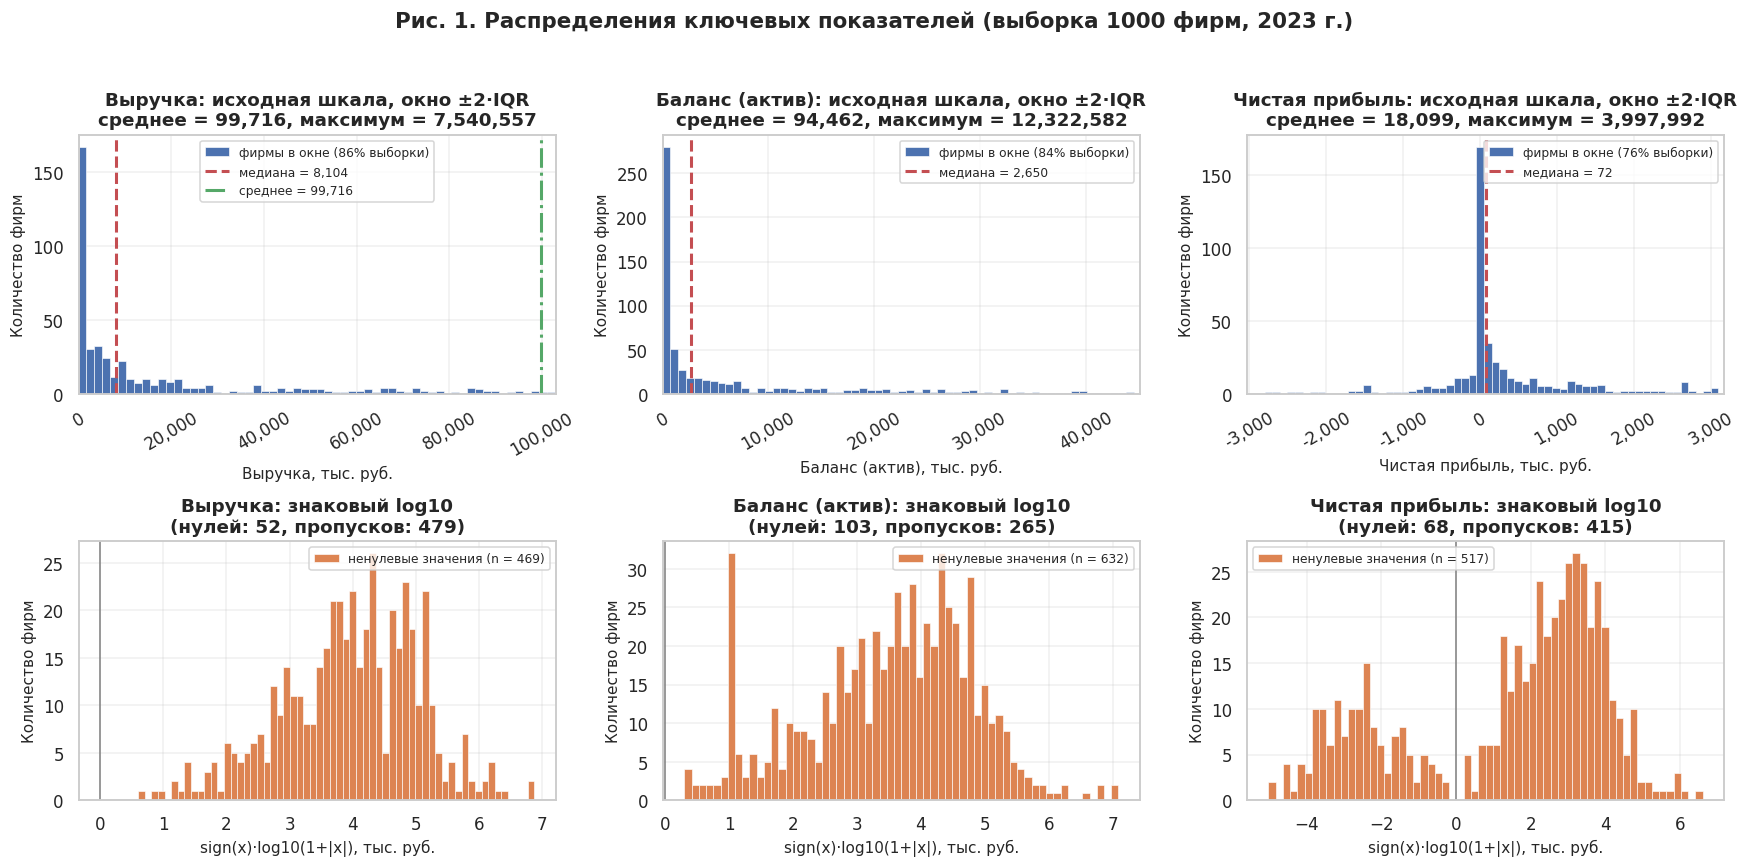

In [7]:
HIST_COLS = ["PL_revenue", "B_assets", "PL_net_profit"]


def signed_log10(s):
    """log10 с сохранением знака — для показателей, принимающих оба знака."""
    return np.sign(s) * np.log10(1 + s.abs())


fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for j, col in enumerate(HIST_COLS):
    data = df[col].dropna()

    # Верхний ряд — исходная шкала. Показываем окно «медиана ± 2·IQR»: на полном диапазоне
    # несколько фирм-гигантов растягивают ось так, что все остальные наблюдения сливаются
    # в один столбик. Даже такое окно охватывает лишь часть фирм — это и есть иллюстрация
    # того, насколько тяжёлый у распределения правый хвост.
    q1, q3 = data.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo = max(data.min(), data.median() - 2 * iqr)
    hi = min(data.max(), data.median() + 2 * iqr)
    if not hi > lo:                                  # вырожденный случай: почти все значения равны
        lo, hi = data.min(), data.min() + 1
    window = data[data.between(lo, hi)]

    ax = axes[0, j]
    ax.hist(window, bins=60, color="#4C72B0", edgecolor="white", linewidth=0.4,
            label=f"фирмы в окне ({len(window) / len(data) * 100:.0f}% выборки)")
    ax.axvline(data.median(), color="#C44E52", ls="--", lw=2, label=f"медиана = {data.median():,.0f}")
    if lo <= data.mean() <= hi:
        ax.axvline(data.mean(), color="#55A868", ls="-.", lw=2, label=f"среднее = {data.mean():,.0f}")
    ax.set_xlim(lo, hi)
    ax.set_title(f"{LABELS_RU[col]}: исходная шкала, окно ±2·IQR\n"
                 f"среднее = {data.mean():,.0f}, максимум = {data.max():,.0f}")
    ax.set_xlabel(f"{LABELS_RU[col]}, тыс. руб.")
    ax.set_ylabel("Количество фирм")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"{v:,.0f}"))
    ax.tick_params(axis="x", labelrotation=30)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # нижний ряд: знаковая логарифмическая шкала, весь хвост целиком
    ax = axes[1, j]
    logged = signed_log10(data[data != 0])
    ax.hist(logged, bins=60, color="#DD8452", edgecolor="white", linewidth=0.4,
            label=f"ненулевые значения (n = {len(logged)})")
    ax.axvline(0, color="grey", lw=1)
    ax.set_title(f"{LABELS_RU[col]}: знаковый log10\n"
                 f"(нулей: {int((data == 0).sum())}, пропусков: {int(df[col].isna().sum())})")
    ax.set_xlabel("sign(x)·log10(1+|x|), тыс. руб.")
    ax.set_ylabel("Количество фирм")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Рис. 1. Распределения ключевых показателей (выборка {len(df)} фирм, {YEAR} г.)",
             fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f"{FIG_DIR}/01_histograms.png")
plt.show()

In [8]:
# формальный поиск выбросов: правило Тьюки (1.5·IQR) + концентрация верхнего хвоста
def outlier_report(s):
    s = s.dropna()          # все доли ниже — от непустых значений
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = s[(s < lo) | (s > hi)]
    top1 = s.nlargest(max(1, int(len(s) * 0.01)))
    positive_sum = s[s > 0].sum()
    return {
        "непустых": len(s),
        "нулей, %": round((s == 0).mean() * 100, 1),
        "отрицательных, %": round((s < 0).mean() * 100, 1),
        "нижняя граница Тьюки": round(lo, 0),
        "верхняя граница Тьюки": round(hi, 0),
        "выбросов по Тьюки, %": round(len(out) / len(s) * 100, 1),
        "максимум": round(s.max(), 0),
        "макс / 99-й перцентиль": round(s.max() / s.quantile(0.99), 1) if s.quantile(0.99) > 0 else np.nan,
        "доля топ-1% в сумме, %": round(top1.sum() / positive_sum * 100, 1) if positive_sum > 0 else np.nan,
    }


display(pd.DataFrame({col: outlier_report(df[col]) for col in HIST_COLS}).T)

print("\nТоп-5 фирм по выручке:")
display(df.nlargest(5, "PL_revenue")[["PL_revenue", "B_assets", "PL_net_profit", "age", "simplified"]])

print("\nСамые убыточные фирмы выборки:")
display(df.nsmallest(5, "PL_net_profit")[["PL_revenue", "B_assets", "PL_net_profit", "B_total_equity"]])

,непустых,"нулей, %","отрицательных, %",нижняя граница Тьюки,верхняя граница Тьюки,"выбросов по Тьюки, %",максимум,макс / 99-й перцентиль,"доля топ-1% в сумме, %"
PL_revenue,521.00,10.00,0.00,"-70,392.00","119,484.00",12.30,"7,540,557.00",4.70,40.40
B_assets,735.00,14.00,0.00,"-31,824.00","53,194.00",14.70,"12,322,582.00",9.10,66.30
PL_net_profit,585.00,11.60,25.00,"-2,330.00","3,882.00",23.90,"3,997,992.00",11.40,71.20



Топ-5 фирм по выручке:


,PL_revenue,B_assets,PL_net_profit,age,simplified
219,"7,540,557.00","12,322,582.00","334,641.00",25.00,0.00
170,"7,076,593.00","7,094,478.00","777,345.00",8.00,0.00
962,"2,839,098.00","1,120,398.00","266,457.00",7.00,0.00
246,"1,901,255.00","353,214.00","62,906.00",5.00,0.00
594,"1,653,916.00","682,201.00","799,433.00",1.00,0.00



Самые убыточные фирмы выборки:


,PL_revenue,B_assets,PL_net_profit,B_total_equity
84,"6,478.00","37,694.00","-106,141.00","-415,846.00"
610,"77,788.00","111,179.00","-68,198.00","-725,464.00"
309,14.00,"202,142.00","-36,042.00","-36,738.00"
580,"51,956.00","47,540.00","-32,261.00","-31,265.00"
33,"178,591.00","101,269.00","-31,962.00","49,006.00"


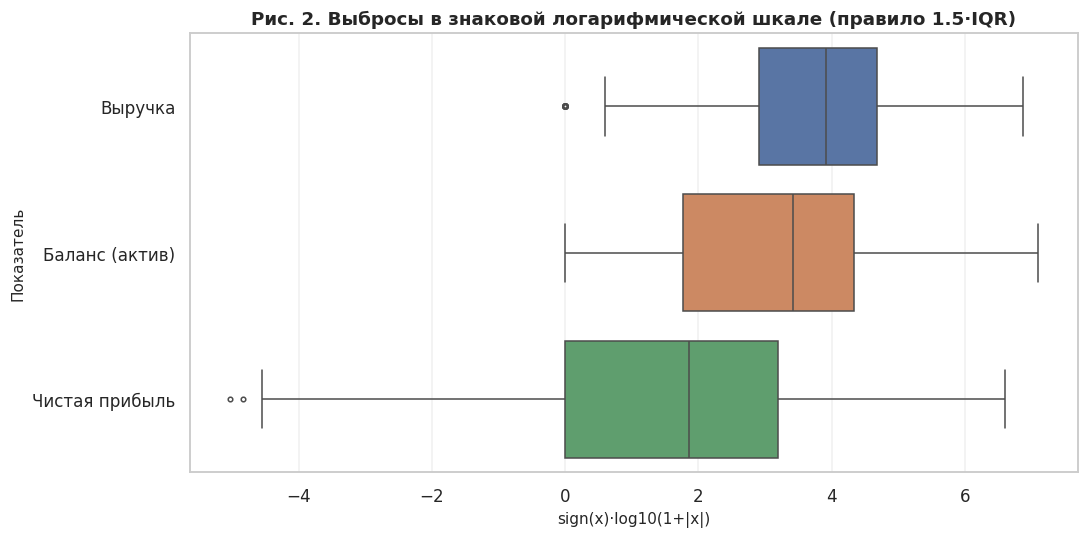

In [9]:
# боксплоты в логарифмической шкале — компактная картина выбросов
box_data = pd.DataFrame({LABELS_RU[col]: signed_log10(df[col]) for col in HIST_COLS})

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=box_data, orient="h", ax=ax, fliersize=3)
ax.set_title("Рис. 2. Выбросы в знаковой логарифмической шкале (правило 1.5·IQR)")
ax.set_xlabel("sign(x)·log10(1+|x|)")
ax.set_ylabel("Показатель")
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/02_boxplots.png")
plt.show()

**Интерпретация рис. 1–2.**

* **Исходная шкала нечитаема без зума.** Максимум отличается от медианы на три-четыре порядка
  (см. подзаголовки верхнего ряда), поэтому на полном диапазоне вся масса наблюдений схлопывается
  в один столбик. Даже окно «медиана ± 2·IQR» вмещает лишь часть выборки (доля указана в легенде),
  а внутри него видно классическое правое скошение: пик у малых значений и монотонно убывающий хвост.
* **Правило Тьюки помечает выбросами порядка 10–25% наблюдений** — это не ошибки данных,
  а естественное логнормальное распределение размера фирм. Отсекать такие «выбросы» по 1.5·IQR
  нельзя: мы удалим весь реальный крупный бизнес.
* **В лог-шкале** распределения выручки и активов становятся почти колоколообразными — прямое
  подтверждение логнормальности.
* **Нули и пропуски.** Ровно нулевые значения дают несколько процентов наблюдений («спящие»
  фирмы, сдавшие пустой отчёт), а вот пропусков — десятки процентов: RFSD намеренно включает
  фирмы, не сдававшие отчётность вовсе. И то, и другое ломает логарифмирование, поэтому в нижнем
  ряду нули исключены явно, а их количество вынесено в подзаголовок.
* **Чистая прибыль двусторонняя:** левый хвост убытков сопоставим по длине с правым хвостом
  прибылей, в лог-шкале распределение почти симметрично и бимодально — фирмы группируются
  вокруг небольших по модулю прибылей и убытков.
* **Верхний хвост экстремально концентрирован:** на топ-1% фирм приходится порядка половины
  суммарной выручки и две трети суммарных активов выборки. Часть таких значений нереалистична:
  авторы RFSD приводят пример ООО с выручкой 3.7 трлн руб. (≈2% ВВП России) и помечают подобные
  фирмы отдельным флагом `outlier`.

## 4. Матрица корреляций (все 20 колонок)

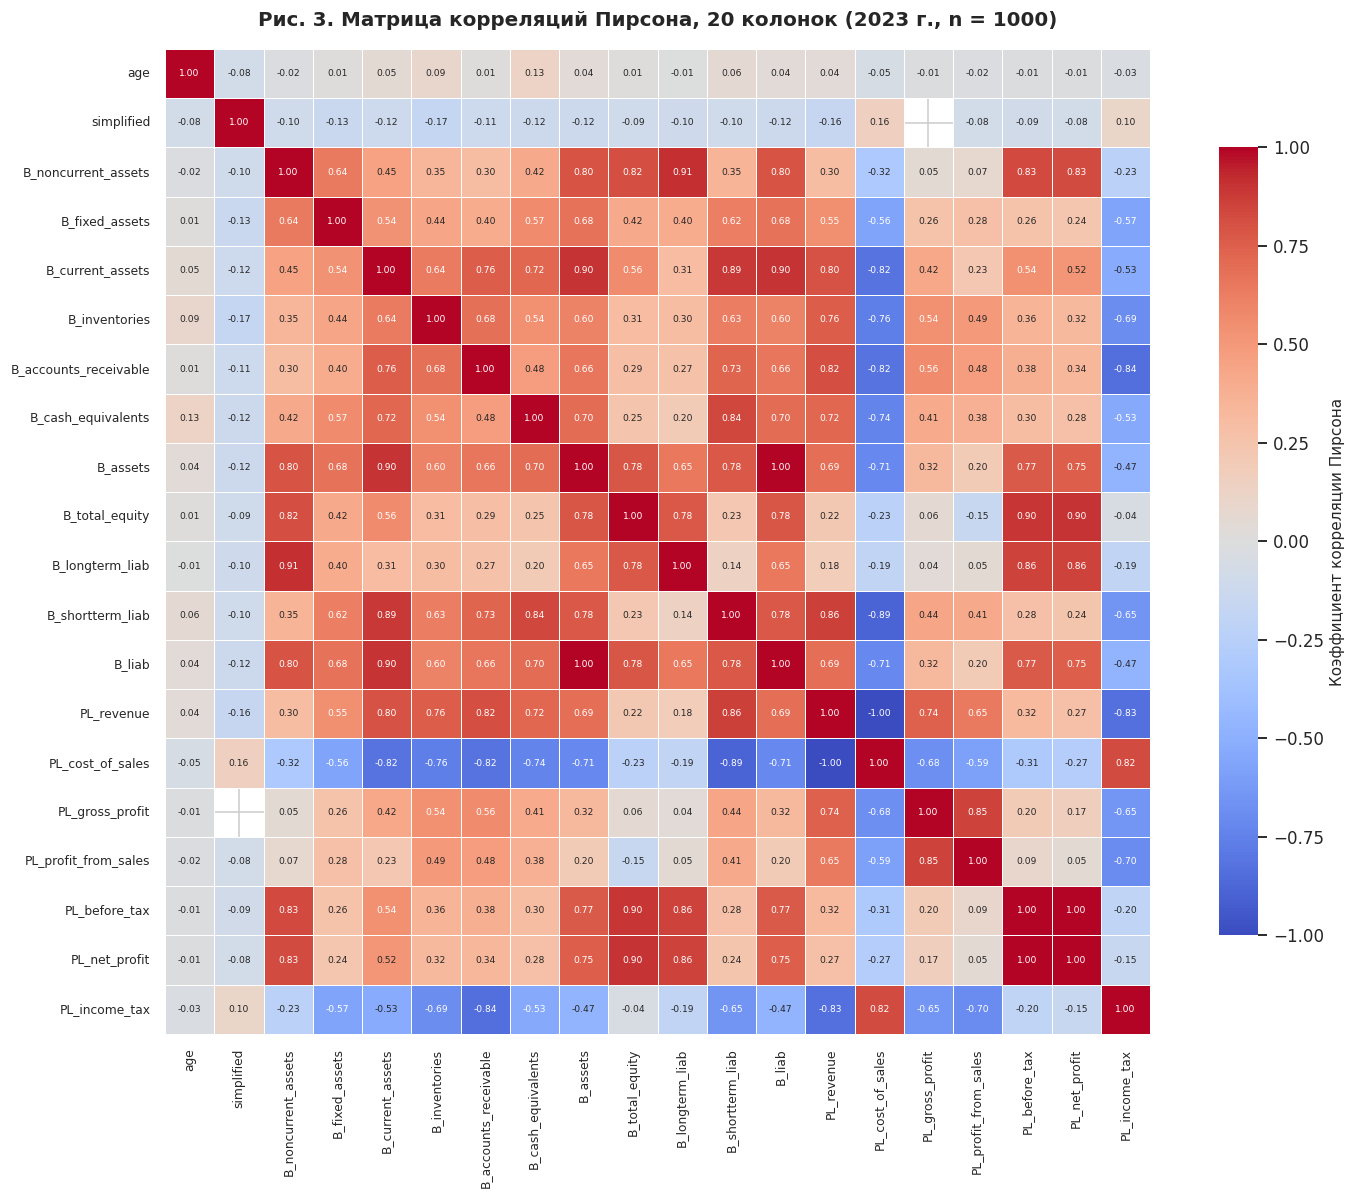

In [10]:
corr = df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt=".2f", annot_kws={"size": 6},
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor="white", square=True,
            cbar_kws={"label": "Коэффициент корреляции Пирсона", "shrink": 0.8}, ax=ax)
ax.set_title(f"Рис. 3. Матрица корреляций Пирсона, 20 колонок ({YEAR} г., n = {len(df)})",
             fontsize=13, fontweight="bold", pad=15)
ax.tick_params(axis="x", labelrotation=90, labelsize=8)
ax.tick_params(axis="y", labelrotation=0, labelsize=8)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/03_corr_pearson.png")
plt.show()

In [11]:
# пары колонок, отсортированные по силе линейной связи
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = (corr.where(mask).stack().rename("r").reset_index()
         .rename(columns={"level_0": "колонка_1", "level_1": "колонка_2"}))
pairs["|r|"] = pairs["r"].abs()

print("ТОП-15 пар по силе связи:")
display(pairs.nlargest(15, "|r|").round(3).reset_index(drop=True))

print("\nПары с самой слабой связью:")
display(pairs.nsmallest(10, "|r|").round(3).reset_index(drop=True))

ТОП-15 пар по силе связи:


,колонка_1,колонка_2,r,|r|
0,B_assets,B_liab,1.00,1.00
1,PL_before_tax,PL_net_profit,1.00,1.00
2,PL_revenue,PL_cost_of_sales,-1.00,1.00
3,B_noncurrent_assets,B_longterm_liab,0.91,0.91
4,B_current_assets,B_assets,0.90,0.90
5,B_current_assets,B_liab,0.90,0.90
6,B_total_equity,PL_net_profit,0.90,0.90
7,B_total_equity,PL_before_tax,0.90,0.90
8,B_current_assets,B_shortterm_liab,0.89,0.89
9,B_shortterm_liab,PL_cost_of_sales,-0.89,0.89



Пары с самой слабой связью:


,колонка_1,колонка_2,r,|r|
0,age,B_longterm_liab,-0.01,0.01
1,age,PL_gross_profit,-0.01,0.01
2,age,PL_before_tax,-0.01,0.01
3,age,PL_net_profit,-0.01,0.01
4,age,B_accounts_receivable,0.01,0.01
5,age,B_fixed_assets,0.01,0.01
6,age,B_total_equity,0.01,0.01
7,age,PL_profit_from_sales,-0.02,0.02
8,age,B_noncurrent_assets,-0.02,0.02
9,age,PL_income_tax,-0.03,0.03


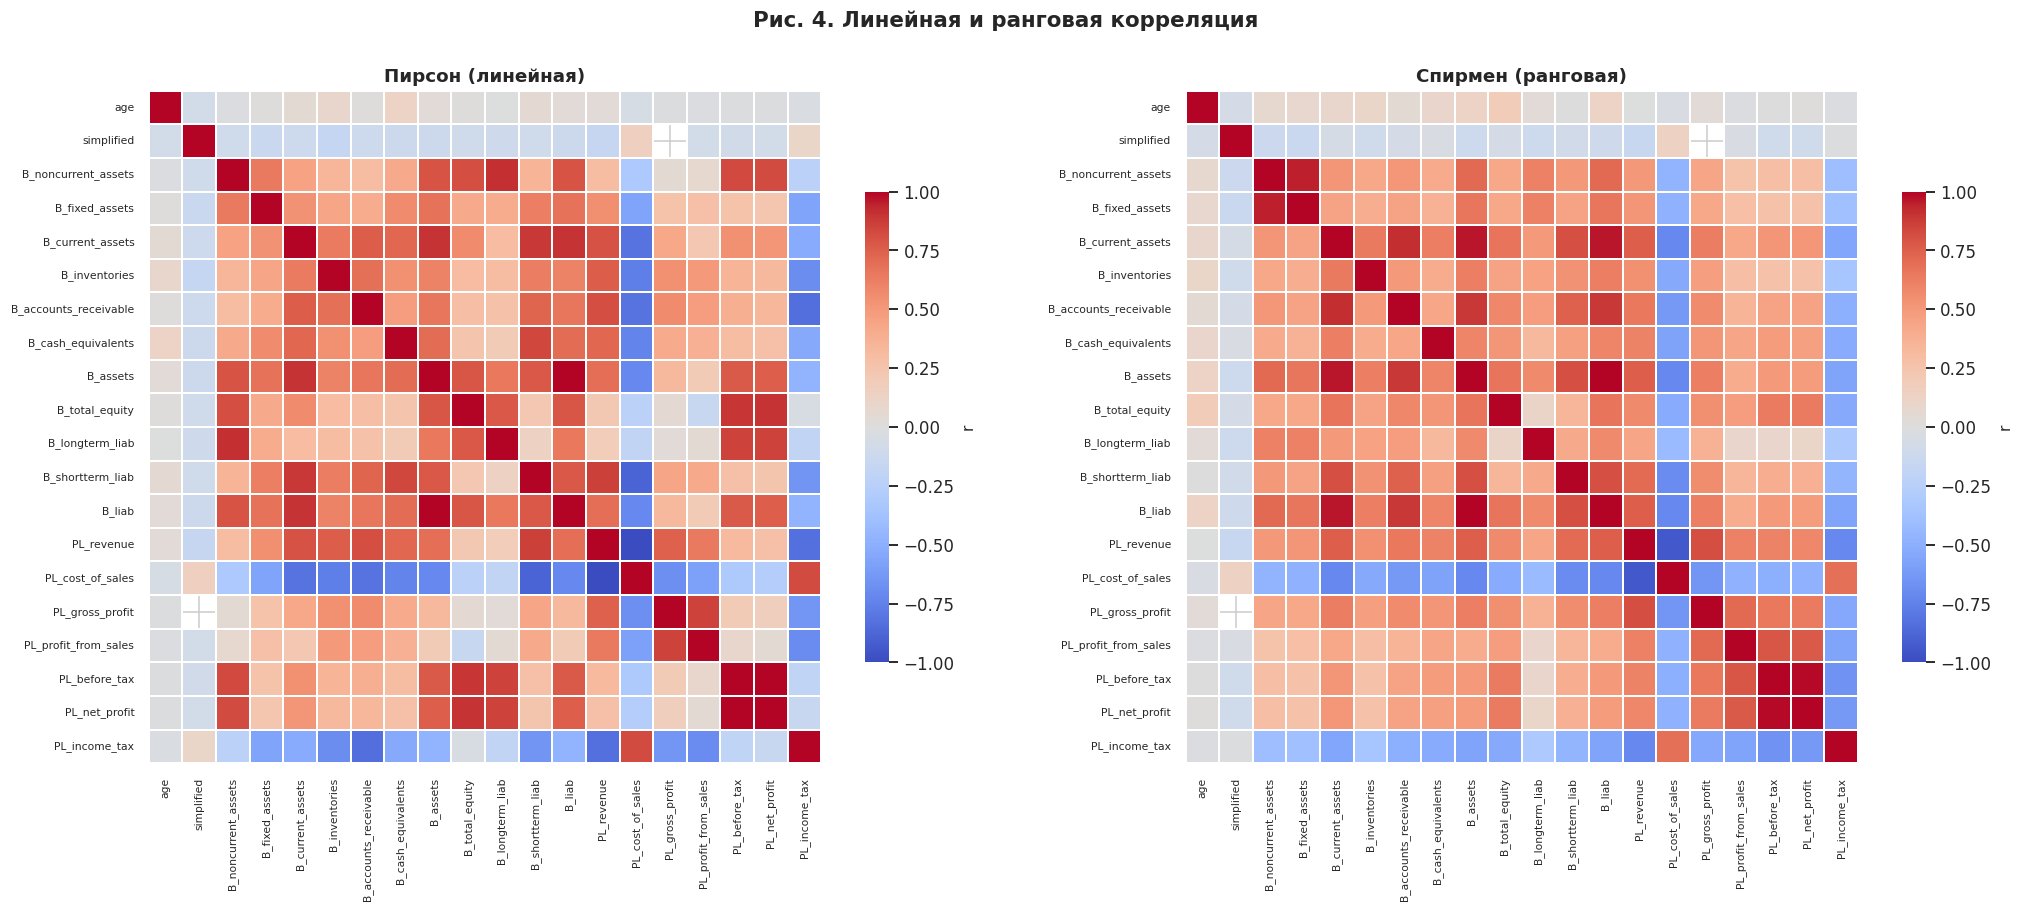

Наибольшее расхождение Спирмена и Пирсона (нелинейность / влияние выбросов):


B_longterm_liab       PL_before_tax          0.76
                      PL_net_profit          0.75
PL_profit_from_sales  PL_net_profit          0.72
                      PL_before_tax          0.70
B_total_equity        B_longterm_liab        0.66
                      PL_profit_from_sales   0.63
B_noncurrent_assets   PL_before_tax          0.54
                      PL_net_profit          0.54
B_total_equity        PL_income_tax          0.50
                      PL_gross_profit        0.50
dtype: float64

In [12]:
# Спирмен устойчив к выбросам и монотонным нелинейностям, поэтому расхождение с Пирсоном информативно
corr_s = df.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(19, 8))
for ax, matrix, name in zip(axes, [corr, corr_s], ["Пирсон (линейная)", "Спирмен (ранговая)"]):
    sns.heatmap(matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
                linewidths=0.3, linecolor="white", ax=ax,
                cbar_kws={"label": "r", "shrink": 0.7})
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", labelrotation=90, labelsize=7)
    ax.tick_params(axis="y", labelrotation=0, labelsize=7)
fig.suptitle("Рис. 4. Линейная и ранговая корреляция", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f"{FIG_DIR}/04_corr_pearson_vs_spearman.png")
plt.show()

diff = (corr_s - corr).abs().where(mask).stack().sort_values(ascending=False)
print("Наибольшее расхождение Спирмена и Пирсона (нелинейность / влияние выбросов):")
display(diff.head(10).round(3))

**Интерпретация рис. 3–4: где связь высокая и почему.**

1. **`B_assets` ↔ `B_liab`, r ≈ 1.00** — это не открытие, а бухгалтерское тождество: строка 1600
   (актив) и строка 1700 (пассив) равны по определению. Такая корреляция работает как тест
   качества данных: отклонение от единицы = битые записи (проверяем в разделе 6).
2. **`B_assets` ↔ `B_current_assets` — около 0.9,** потому что 1600 = 1100 + 1200, а внеоборотные
   активы у большинства фирм малы или отсутствуют, так что валюта баланса почти совпадает
   с оборотными активами. Аналогично устроено 1700 = 1300 + 1400 + 1500. Блоки «слипшихся»
   переменных — предупреждение для ML: включать все строки баланса в линейную модель нельзя,
   это идеальная мультиколлинеарность.
3. **`PL_revenue` ↔ `PL_cost_of_sales` — сильная связь с отрицательным знаком.** Экономически
   связь прямая (больше продаёшь — больше себестоимость), минус возникает только из-за знакового
   соглашения RFSD. Это самая обманчивая корреляция в датасете: не зная соглашения, легко сделать
   вывод «рост выручки снижает издержки».
4. **Цепочка прибыли** `PL_gross_profit` → `PL_profit_from_sales` → `PL_before_tax` →
   `PL_net_profit` сильно скоррелирована внутри себя: каждый следующий показатель получается
   вычитанием сравнительно небольших статей из предыдущего. Сюда же `PL_net_profit` ↔
   `PL_income_tax` — налог считается от прибыли.
5. **`B_noncurrent_assets` ↔ `B_longterm_liab` (≈0.9) — уже не тождество, а экономика:**
   капиталоёмкие фирмы финансируют внеоборотные активы длинными деньгами, это классическое
   правило соответствия сроков активов и пассивов.
6. **Слабые связи** дают `age` и `simplified`: линейная корреляция возраста фирмы с финансовыми
   показателями практически нулевая (|r| ≈ 0.01–0.03) — возраст сам по себе ничего не говорит
   о размере. У `simplified` связь с масштабом отрицательная (крупные фирмы не имеют права
   на упрощённую форму), и у Спирмена она заметно сильнее, чем у Пирсона.
7. **Расхождение Пирсона и Спирмена** максимально там, где связь монотонная, но резко нелинейная.
   Показательный случай — выручка и чистая прибыль: Пирсон заметно **ниже** Спирмена, потому что
   в исходной шкале его «перетягивают» несколько фирм-гигантов и редкие крупные убытки,
   а ранговый коэффициент видит устойчивую монотонную связь.
8. **Осторожно с числом наблюдений.** `corr()` считает каждую пару по строкам, где заполнены обе
   колонки, а заполненность у разных строк отчётности разная. Поэтому корреляции в матрице
   опираются на разное число фирм, и пары с редкими колонками (например, `PL_gross_profit`)
   менее надёжны.

## 5. Диаграммы рассеивания коррелирующих колонок

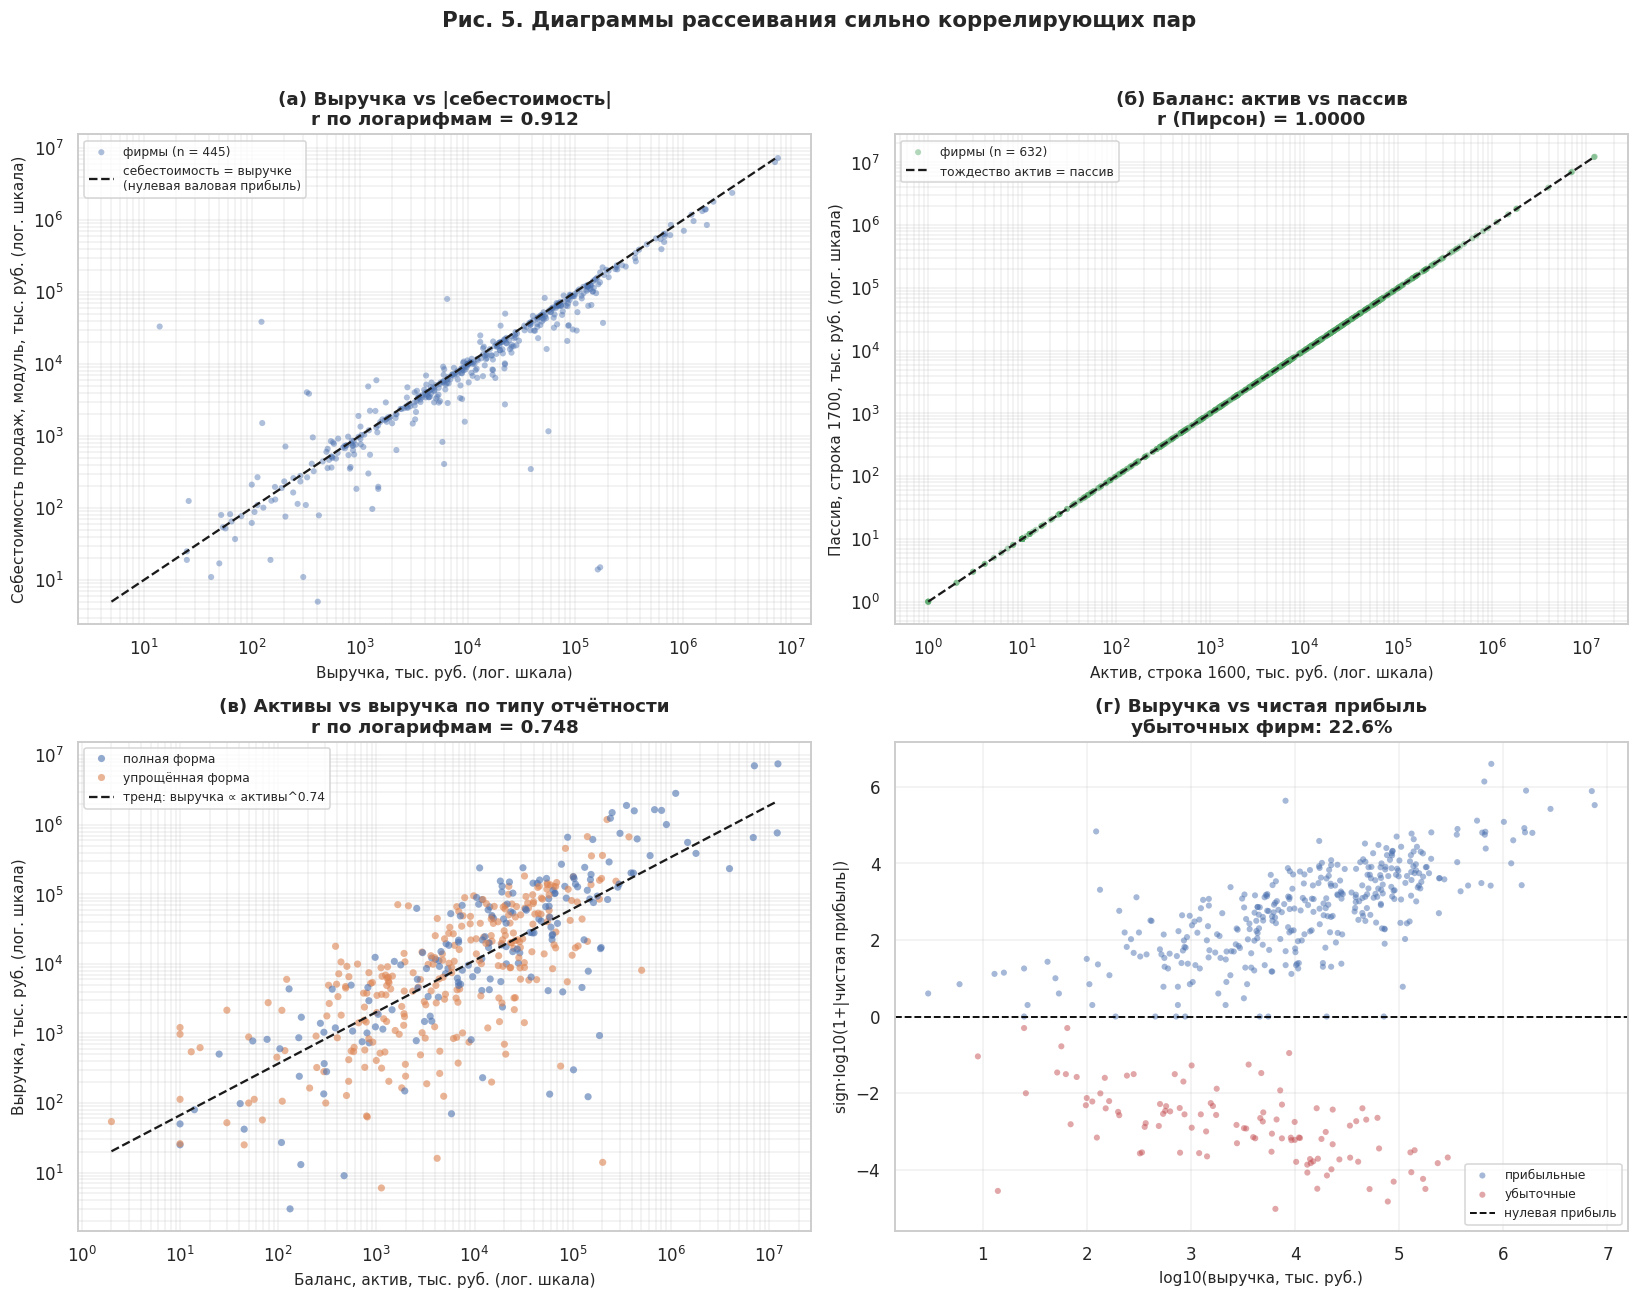

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# (а) выручка vs себестоимость, знак себестоимости развёрнут
ax = axes[0, 0]
sub = df[(df["PL_revenue"] > 0) & (df["PL_cost_of_sales"].abs() > 0)].copy()
sub["cost_abs"] = sub["PL_cost_of_sales"].abs()
r_a = np.corrcoef(np.log10(sub["PL_revenue"]), np.log10(sub["cost_abs"]))[0, 1]
ax.scatter(sub["PL_revenue"], sub["cost_abs"], s=16, alpha=0.45, color="#4C72B0",
           edgecolor="none", label=f"фирмы (n = {len(sub)})")
lims = [min(sub["PL_revenue"].min(), sub["cost_abs"].min()),
        max(sub["PL_revenue"].max(), sub["cost_abs"].max())]
ax.plot(lims, lims, "k--", lw=1.5, label="себестоимость = выручке\n(нулевая валовая прибыль)")
ax.set(xscale="log", yscale="log")
ax.set_title(f"(а) Выручка vs |себестоимость|\nr по логарифмам = {r_a:.3f}")
ax.set_xlabel("Выручка, тыс. руб. (лог. шкала)")
ax.set_ylabel("Себестоимость продаж, модуль, тыс. руб. (лог. шкала)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, which="both", alpha=0.3)

# (б) проверка тождества 1600 = 1700
ax = axes[0, 1]
sub2 = df[(df["B_assets"] > 0) & (df["B_liab"] > 0)]
r_b = df[["B_assets", "B_liab"]].corr().iloc[0, 1]
ax.scatter(sub2["B_assets"], sub2["B_liab"], s=16, alpha=0.45, color="#55A868",
           edgecolor="none", label=f"фирмы (n = {len(sub2)})")
lims2 = [sub2[["B_assets", "B_liab"]].min().min(), sub2[["B_assets", "B_liab"]].max().max()]
ax.plot(lims2, lims2, "k--", lw=1.5, label="тождество актив = пассив")
ax.set(xscale="log", yscale="log")
ax.set_title(f"(б) Баланс: актив vs пассив\nr (Пирсон) = {r_b:.4f}")
ax.set_xlabel("Актив, строка 1600, тыс. руб. (лог. шкала)")
ax.set_ylabel("Пассив, строка 1700, тыс. руб. (лог. шкала)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, which="both", alpha=0.3)

# (в) активы vs выручка с разбивкой по типу отчётности
ax = axes[1, 0]
sub3 = df[(df["PL_revenue"] > 0) & (df["B_assets"] > 0)].copy()
sub3["Тип отчётности"] = sub3["simplified"].map({0.0: "полная форма", 1.0: "упрощённая форма"}).fillna("нет данных")
log_x, log_y = np.log10(sub3["B_assets"]), np.log10(sub3["PL_revenue"])
r_c = np.corrcoef(log_x, log_y)[0, 1]
sns.scatterplot(data=sub3, x="B_assets", y="PL_revenue", hue="Тип отчётности",
                s=22, alpha=0.6, edgecolor="none", ax=ax)
if len(sub3) > 10:                                   # степенной закон: выручка ~ активы^slope
    slope, intercept = np.polyfit(log_x, log_y, 1)
    grid = np.linspace(log_x.min(), log_x.max(), 100)
    ax.plot(10 ** grid, 10 ** (intercept + slope * grid), "k--", lw=1.5,
            label=f"тренд: выручка ∝ активы^{slope:.2f}")
ax.set(xscale="log", yscale="log")
ax.set_title(f"(в) Активы vs выручка по типу отчётности\nr по логарифмам = {r_c:.3f}")
ax.set_xlabel("Баланс, актив, тыс. руб. (лог. шкала)")
ax.set_ylabel("Выручка, тыс. руб. (лог. шкала)")
ax.legend(fontsize=8, title=None, loc="upper left")
ax.grid(True, which="both", alpha=0.3)

# (г) выручка vs чистая прибыль в знаковых логарифмах
ax = axes[1, 1]
sub4 = df[(df["PL_revenue"] > 0) & df["PL_net_profit"].notna()].copy()
share_loss = (sub4["PL_net_profit"] < 0).mean() * 100
profitable = sub4["PL_net_profit"] >= 0
for flag, color, name in [(profitable, "#4C72B0", "прибыльные"), (~profitable, "#C44E52", "убыточные")]:
    ax.scatter(np.log10(sub4.loc[flag, "PL_revenue"]), signed_log10(sub4.loc[flag, "PL_net_profit"]),
               s=16, alpha=0.5, color=color, edgecolor="none", label=name)
ax.axhline(0, color="black", lw=1.2, ls="--", label="нулевая прибыль")
ax.set_title(f"(г) Выручка vs чистая прибыль\nубыточных фирм: {share_loss:.1f}%")
ax.set_xlabel("log10(выручка, тыс. руб.)")
ax.set_ylabel("sign·log10(1+|чистая прибыль|)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.3)

fig.suptitle("Рис. 5. Диаграммы рассеивания сильно коррелирующих пар", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(f"{FIG_DIR}/05_scatter.png")
plt.show()

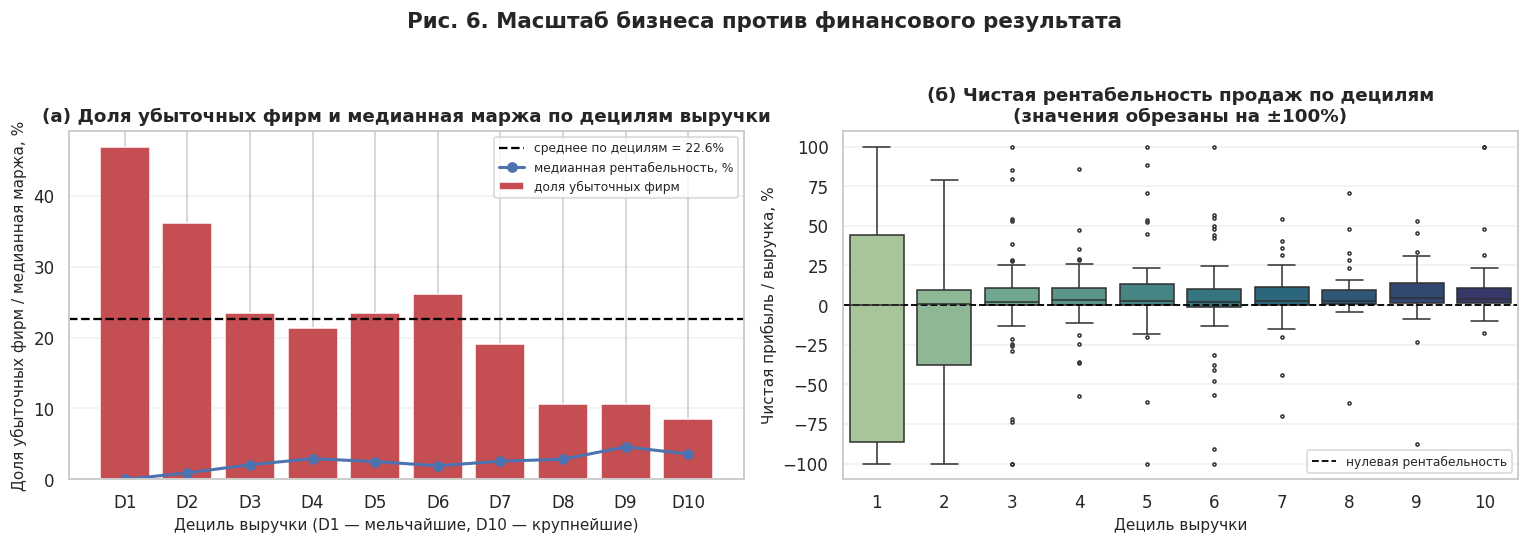

Корреляция выручки и чистой прибыли:
  Пирсон : 0.275
  Спирмен: 0.580
  Межквартильный размах рентабельности: 11.6 п.п.


,фирм,из них с известной прибылью,"доля убыточных, %","медианная маржа, %","размах маржи (75%−25%), п.п."
decile,,,,,
1,47,47,46.80,0.00,130.60
2,47,47,36.20,0.90,47.40
3,47,47,23.40,2.10,10.50
4,47,47,21.30,2.90,10.50
5,47,47,23.40,2.50,13.10
6,46,46,26.10,1.90,11.20
7,47,47,19.10,2.60,11.10
8,47,47,10.60,2.80,8.80
9,47,47,10.60,4.60,12.70


In [14]:
# количественная проверка гипотезы «размер не определяет результат»
pos = df[df["PL_revenue"] > 0].copy()
pos["margin"] = pos["PL_net_profit"] / pos["PL_revenue"] * 100
pos["decile"] = pd.qcut(pos["PL_revenue"], 10, labels=False, duplicates="drop") + 1
order = sorted(pos["decile"].dropna().unique())

by_dec = pos.groupby("decile", observed=True).agg(
    firms=("margin", "size"),
    known_profit=("PL_net_profit", "count"),
    # долю убыточных считаем от фирм с известной прибылью, а не от всех строк дециля
    loss_share=("PL_net_profit", lambda s: (s < 0).sum() / max(s.notna().sum(), 1) * 100),
    median_margin=("margin", "median"),
    margin_iqr=("margin", lambda s: s.quantile(0.75) - s.quantile(0.25)),
).rename(columns={"firms": "фирм", "known_profit": "из них с известной прибылью",
                  "loss_share": "доля убыточных, %", "median_margin": "медианная маржа, %",
                  "margin_iqr": "размах маржи (75%−25%), п.п."})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar([f"D{d}" for d in by_dec.index], by_dec["доля убыточных, %"],
       color="#C44E52", edgecolor="white", label="доля убыточных фирм")
ax.axhline(by_dec["доля убыточных, %"].mean(), color="black", ls="--", lw=1.5,
           label=f"среднее по децилям = {by_dec['доля убыточных, %'].mean():.1f}%")
ax.plot([f"D{d}" for d in by_dec.index], by_dec["медианная маржа, %"], color="#4C72B0",
        marker="o", lw=2, label="медианная рентабельность, %")
ax.set_title("(а) Доля убыточных фирм и медианная маржа по децилям выручки")
ax.set_xlabel("Дециль выручки (D1 — мельчайшие, D10 — крупнейшие)")
ax.set_ylabel("Доля убыточных фирм / медианная маржа, %")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.3)

ax = axes[1]
sns.boxplot(data=pos.assign(margin=pos["margin"].clip(-100, 100)), x="decile", y="margin",
            order=order, hue="decile", palette="crest", legend=False, fliersize=2, ax=ax)
ax.axhline(0, color="black", ls="--", lw=1.2, label="нулевая рентабельность")
ax.set_title("(б) Чистая рентабельность продаж по децилям\n(значения обрезаны на ±100%)")
ax.set_xlabel("Дециль выручки")
ax.set_ylabel("Чистая прибыль / выручка, %")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Рис. 6. Масштаб бизнеса против финансового результата", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(f"{FIG_DIR}/06_margin_by_decile.png")
plt.show()

print("Корреляция выручки и чистой прибыли:")
print(f"  Пирсон : {df[['PL_revenue', 'PL_net_profit']].corr().iloc[0, 1]:.3f}")
print(f"  Спирмен: {df[['PL_revenue', 'PL_net_profit']].corr(method='spearman').iloc[0, 1]:.3f}")
print(f"  Межквартильный размах рентабельности: "
      f"{pos['margin'].quantile(0.75) - pos['margin'].quantile(0.25):.1f} п.п.")
display(by_dec.round(1))

**Интерпретация рис. 5–6.**

* **(а) Выручка ↔ себестоимость.** Облако вытянуто вдоль биссектрисы на протяжении шести-семи
  порядков: эластичность близка к единице, себестоимость растёт почти пропорционально выручке,
  хотя разброс вокруг диагонали заметный — маржинальность у фирм разная. Точки выше пунктира —
  фирмы, продающие ниже себестоимости (отрицательная валовая прибыль). После разворота знака
  корреляция становится сильно положительной: минус в матрице корреляций — техническое
  соглашение о знаках, а не экономический эффект.
* **(б) Актив ↔ пассив.** Практически все точки лежат ровно на прямой `y = x` — бухгалтерское
  тождество соблюдается, данные внутренне согласованы (RFSD специально проверяет сходимость форм).
  Точки в стороне от прямой — кандидаты в ошибочные записи.
* **(в) Активы ↔ выручка.** В лог-лог координатах связь линейная — это степенной закон
  `выручка ≈ const · активы^α`, наклон пунктира и есть оценка α. Корреляция по логарифмам высокая,
  но далеко не единичная: при одних и тех же активах выручка различается на порядки — фондоёмкость
  сильно зависит от отрасли. Неожиданная деталь: окраска по `simplified` делит облако на две зоны,
  фирмы на упрощённой отчётности сидят в левом нижнем углу. Формальный признак «какую форму
  отчётности сдала фирма» оказывается хорошим прокси размера бизнеса.
* **(г) Выручка ↔ чистая прибыль.** Облако размазано по вертикали: при любой выручке встречаются
  и прибыль, и убыток. Здесь же виден разрыв между коэффициентами — Пирсон заметно ниже Спирмена
  (см. печать под рис. 6): в исходной шкале связь портят несколько гигантов и редкие крупные
  убытки, а по рангам монотонная зависимость видна отчётливо.
* **Рис. 6 уточняет картину и частично опровергает простую гипотезу «размер не влияет».**
  Доля убыточных фирм **систематически снижается** от нижних децилей выручки к верхним — мелкие
  фирмы уходят в минус в разы чаще крупных. Но медианная рентабельность при этом остаётся
  в пределах нескольких процентов во всех децилях, а межквартильный размах маржи внутри дециля
  в разы больше, чем разница медиан между децилями. Вывод: **размер связан с вероятностью
  сработать в убыток, но почти не определяет уровень рентабельности** — для предсказания маржи
  абсолютные показатели размера бесполезны.

## 6. Проверка бухгалтерских тождеств и аномалии

Матрица корреляций подсказала, что часть колонок связана детерминированно. Проверяем тождества
построчно: нарушение — это либо ошибка исходной отчётности, либо артефакт восстановления данных.
Для отчёта о финансовых результатах проверяем обе версии знака, чтобы подтвердить соглашение RFSD.

In [15]:
checks = {
    "1600 = 1700 (актив = пассив)":
        df["B_assets"] - df["B_liab"],
    "1600 = 1100 + 1200":
        df["B_assets"] - (df["B_noncurrent_assets"] + df["B_current_assets"]),
    "1700 = 1300 + 1400 + 1500":
        df["B_liab"] - (df["B_total_equity"] + df["B_longterm_liab"] + df["B_shortterm_liab"]),
    "2100 = 2110 + 2120 (себестоимость хранится со знаком «−»)":
        df["PL_gross_profit"] - (df["PL_revenue"] + df["PL_cost_of_sales"]),
    "2100 = 2110 − 2120 (себестоимость хранится со знаком «+»)":
        df["PL_gross_profit"] - (df["PL_revenue"] - df["PL_cost_of_sales"]),
}

scale = df["B_assets"].abs().replace(0, np.nan)
rows = []
for name, resid in checks.items():
    resid = resid.dropna()
    rows.append({
        "тождество": name,
        "проверено строк": len(resid),
        "нарушений (|разница| > 1)": int((resid.abs() > 1).sum()),
        "доля нарушений, %": round((resid.abs() > 1).mean() * 100, 2),
        "макс. |разница|": round(resid.abs().max(), 0),
        "медианная отн. ошибка, %": round((resid.abs() / scale).dropna().median() * 100, 4),
    })
display(pd.DataFrame(rows))

def share(mask, column):
    # доля в % от фирм, у которых эта колонка заполнена
    return mask.sum() / max(df[column].notna().sum(), 1) * 100


anomalies = pd.Series({
    "нет данных о выручке (не сдавали отчётность), % от всех": df["PL_revenue"].isna().mean() * 100,
    "нулевая выручка, % от сдавших": share(df["PL_revenue"] == 0, "PL_revenue"),
    "нулевой баланс, % от сдавших": share(df["B_assets"] == 0, "B_assets"),
    "отрицательный собственный капитал, % от сдавших": share(df["B_total_equity"] < 0, "B_total_equity"),
    "убыточных, % от сдавших": share(df["PL_net_profit"] < 0, "PL_net_profit"),
    "упрощённая отчётность, % от сдавших": share(df["simplified"] == 1, "simplified"),
    "доля топ-1% фирм в суммарной выручке, %":
        df["PL_revenue"].nlargest(max(1, len(df) // 100)).sum() / df["PL_revenue"].sum() * 100,
    "доля топ-10% фирм в суммарной выручке, %":
        df["PL_revenue"].nlargest(max(1, len(df) // 10)).sum() / df["PL_revenue"].sum() * 100,
}).round(1)
print("\nЭкономические аномалии и концентрация:")
display(anomalies.to_frame("значение"))

,тождество,проверено строк,нарушений (|разница| > 1),"доля нарушений, %",макс. |разница|,"медианная отн. ошибка, %"
0,1600 = 1700 (актив = пассив),735,1,0.14,2.00,0.00
1,1600 = 1100 + 1200,337,0,0.00,1.00,0.00
2,1700 = 1300 + 1400 + 1500,268,0,0.00,1.00,0.00
3,2100 = 2110 + 2120 (себестоимость хранится со ...,183,0,0.00,0.00,0.00
4,2100 = 2110 − 2120 (себестоимость хранится со ...,183,166,90.71,"14,394,800.00",172.71



Экономические аномалии и концентрация:


,значение
"нет данных о выручке (не сдавали отчётность), % от всех",47.90
"нулевая выручка, % от сдавших",10.00
"нулевой баланс, % от сдавших",14.00
"отрицательный собственный капитал, % от сдавших",18.20
"убыточных, % от сдавших",25.00
"упрощённая отчётность, % от сдавших",61.00
"доля топ-1% фирм в суммарной выручке, %",54.20
"доля топ-10% фирм в суммарной выручке, %",90.30


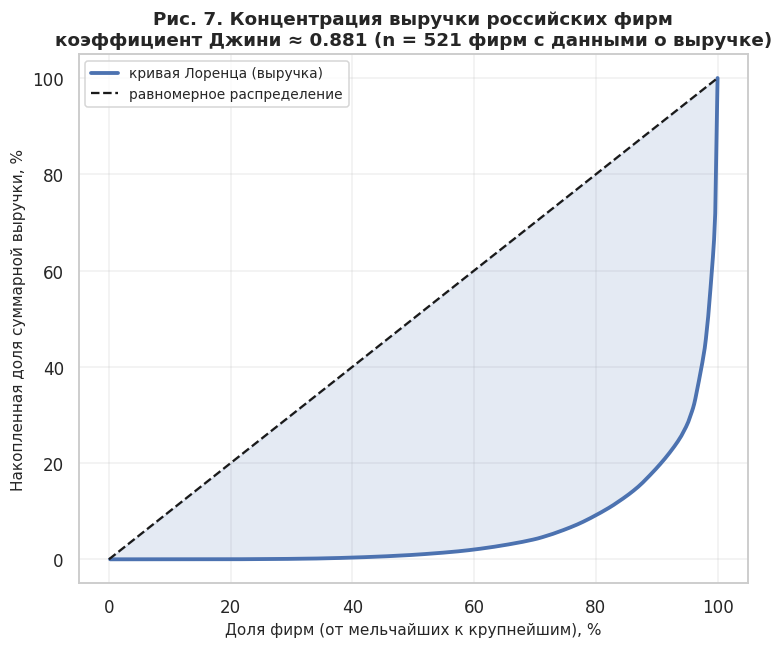

In [16]:
# концентрация выручки: кривая Лоренца и коэффициент Джини
trapezoid = getattr(np, "trapezoid", None) or np.trapz

rev = df["PL_revenue"].dropna().clip(lower=0).sort_values().to_numpy()
cum_share = np.cumsum(rev) / rev.sum()
x = np.arange(1, len(rev) + 1) / len(rev)
gini = 1 - 2 * trapezoid(cum_share, x)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(x * 100, cum_share * 100, lw=2.5, color="#4C72B0", label="кривая Лоренца (выручка)")
ax.plot([0, 100], [0, 100], "k--", lw=1.5, label="равномерное распределение")
ax.fill_between(x * 100, cum_share * 100, x * 100, alpha=0.15, color="#4C72B0")
ax.set_title(f"Рис. 7. Концентрация выручки российских фирм\n"
             f"коэффициент Джини ≈ {gini:.3f} (n = {len(rev)} фирм с данными о выручке)")
ax.set_xlabel("Доля фирм (от мельчайших к крупнейшим), %")
ax.set_ylabel("Накопленная доля суммарной выручки, %")
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/07_lorenz.png")
plt.show()

**Интерпретация рис. 7 и таблицы тождеств.**

* Тождество **актив = пассив** выполняется практически для всех наблюдений — данные RFSD
  внутренне согласованы, единичные нарушения стоит помечать и исключать из моделирования.
* Из двух версий тождества по валовой прибыли выполняется вариант **со сложением**
  (`2100 = 2110 + 2120`) — прямое доказательство того, что расходные строки хранятся со знаком «−».
* Обратите внимание на колонку «проверено строк»: тождества проверяются только там, где заполнены
  обе части, а из-за пропусков это заметно меньше 1000 наблюдений. Меньше всего проверок у
  тождества с валовой прибылью — строки 2100 нет в упрощённой форме отчётности.
* Кривая Лоренца прижата к правому нижнему углу, коэффициент Джини по выручке — около 0.9,
  заметно выше неравенства доходов населения. Экономика российских фирм устроена как «несколько
  гигантов плюс длинный хвост микробизнеса».

## 7. Выводы

In [17]:
# ключевые числа, на которые опираются выводы
summary = {
    "медиана выручки": df["PL_revenue"].median(),
    "средняя выручка": df["PL_revenue"].mean(),
    "коэффициент асимметрии (выручка)": df["PL_revenue"].skew(),
    "r(B_assets, B_liab)": df[["B_assets", "B_liab"]].corr().iloc[0, 1],
    "r(PL_revenue, PL_cost_of_sales)": df[["PL_revenue", "PL_cost_of_sales"]].corr().iloc[0, 1],
    "r(log выручка, log активы)": r_c,
    "r(PL_revenue, PL_net_profit), Пирсон": df[["PL_revenue", "PL_net_profit"]].corr().iloc[0, 1],
    "r(PL_revenue, PL_net_profit), Спирмен":
        df[["PL_revenue", "PL_net_profit"]].corr(method="spearman").iloc[0, 1],
    "Джини по выручке": gini,
    "средняя доля пропусков по 20 колонкам, %": df.isna().mean().mean() * 100,
}
for key, value in summary.items():
    print(f"{key:42s} {value:>18,.3f}")

медиана выручки                                     8,104.000
средняя выручка                                    99,716.121
коэффициент асимметрии (выручка)                       11.752
r(B_assets, B_liab)                                     1.000
r(PL_revenue, PL_cost_of_sales)                        -0.996
r(log выручка, log активы)                              0.748
r(PL_revenue, PL_net_profit), Пирсон                    0.275
r(PL_revenue, PL_net_profit), Спирмен                   0.580
Джини по выручке                                        0.881
средняя доля пропусков по 20 колонкам, %               44.580


**1. Размер фирмы распределён логнормально, «средняя фирма» — фикция.** Среднее превышает медиану
в десятки раз, коэффициент асимметрии — десятки, коэффициент Джини по выручке около 0.9, на топ-1%
фирм приходится примерно половина всей выручки выборки. Следствие для моделирования: денежные
признаки нужно логарифмировать или переходить к рангам и относительным коэффициентам, иначе
линейная модель и любая метрика на основе MSE будут обучаться на нескольких фирмах-гигантах.

**2. Значительная часть высоких корреляций — бухгалтерские тождества, а не экономика.** Пары
`B_assets`–`B_liab`, `B_assets`–(`B_current_assets` + `B_noncurrent_assets`),
`PL_gross_profit`–(`PL_revenue` + `PL_cost_of_sales`) связаны с r ≈ 1 по определению. Это
одновременно инструмент валидации (нарушение тождества = битая запись) и ловушка: включение всех
строк отчётности в модель даёт идеальную мультиколлинеарность, а в задаче предсказания прибыли —
утечку целевой переменной, потому что прибыль арифметически выводится из соседних строк.

**3. Знаки в данных обманчивы.** Сильная отрицательная корреляция выручки и себестоимости —
артефакт формата: расходные строки (себестоимость, налог на прибыль, проценты к уплате) хранятся
со знаком «минус», как они печатаются в скобках в оригинальных формах. Проверка тождеств в
разделе 6 это подтверждает, а после разворота знака связь становится сильно положительной.
Без чтения документации датасета вывод получился бы содержательно противоположным.

**4. Масштаб предсказывает масштаб, но не рентабельность.** Выручка и активы связаны степенным
законом (в лог-лог координатах — прямая с наклоном α), при этом связь выручки с чистой прибылью
куда слабее, а Пирсон здесь ниже Спирмена — линейный коэффициент портят несколько гигантов.
Разбивка по децилям выручки даёт более тонкую картину, чем «размер не влияет вообще»: доля
убыточных фирм с ростом выручки **систематически падает** (мелкие уходят в минус в разы чаще),
но медианная рентабельность во всех децилях держится в пределах нескольких процентов, а разброс
маржи внутри дециля в разы больше разницы между децилями. То есть размер связан с вероятностью
убытка, а не с уровнем маржи; для предсказания рентабельности нужны относительные показатели
(маржа, оборачиваемость, долговая нагрузка), а не абсолютные суммы.

**5. Главная особенность данных — не выбросы, а пропуски, и они не случайны.** Заполненность
колонок гуляет от четверти до четырёх пятых, причём по понятной причине: RFSD намеренно включает
фирмы, не сдававшие отчётность, а упрощённая форма содержит меньше строк, чем полная (валовой
прибыли в ней нет вовсе). Административный флаг `simplified` при этом работает как прокси размера
— право на упрощённую форму имеют только малые предприятия, и на диаграмме «активы–выручка»
он делит облако на две зоны. Всё вместе это классический механизм MNAR: заполнять пропуски нулями
или средними без учёта `simplified` и факта сдачи отчётности нельзя, а сама заполненность строки
— полноценный признак для модели.

**6. Аномалии, о которых надо помнить.** Фирмы с ровно нулевой выручкой и нулевым балансом
(«спящие» — включены намеренно), фирмы с отрицательным собственным капиталом (техническая
несостоятельность) и заведомо нереалистичные значения в верхнем хвосте, для которых в RFSD
предусмотрен флаг `outlier` — его стоит подгружать при любом серьёзном исследовании.